In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 13.0 MB/s  0:00:00

   ------------- -------------------------- 2/6 [seaborn]
   ------------- -------------------------- 2/6 [seaborn]
   ------------- -------------------------- 2/6 [seaborn]
   ------------- -------------------------- 2/6 [seaborn]
   -------------------- ------------------- 3/6 [ipywidgets]
   -------------------- ------------------- 3/6 [ipywidgets]
   -------------------- ------------------- 3/6 [ipywidgets]
   -------------------- ------------------- 3/6 [ipywidgets]
   -------------------------- ------------- 4/6 [jupyter-console]
   ---------------------------------------- 6/6 [jupyter]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [11]:
import os

print(os.listdir("data/raw"))

['HousingData.csv']


In [16]:
df = pd.read_csv("data/raw/HousingData.csv")
print("Shape:", df.shape)

Shape: (506, 14)


In [26]:
feature_description = {
    "CRIM": "Per capita crime rate by town",
    "ZN": "Proportion of residential land zoned for large lots",
    "INDUS": "Proportion of non-retail business acres",
    "CHAS": "Charles River dummy variable (1 if tract bounds river, else 0)",
    "NOX": "Nitric oxide concentration",
    "RM": "Average number of rooms per dwelling",
    "AGE": "Proportion of owner-occupied units built before 1940",
    "DIS": "Weighted distance to employment centers",
    "RAD": "Index of accessibility to radial highways",
    "TAX": "Full-value property-tax rate",
    "PTRATIO": "Pupil-teacher ratio by town",
    "B": "Proportion of Black population",
    "LSTAT": "Percentage of lower-status population",
    "MEDV": "Median value of owner-occupied homes"
}

for feature, description in feature_description.items():
    print(f"{feature}: {description}")

CRIM: Per capita crime rate by town
ZN: Proportion of residential land zoned for large lots
INDUS: Proportion of non-retail business acres
CHAS: Charles River dummy variable (1 if tract bounds river, else 0)
NOX: Nitric oxide concentration
RM: Average number of rooms per dwelling
AGE: Proportion of owner-occupied units built before 1940
DIS: Weighted distance to employment centers
RAD: Index of accessibility to radial highways
TAX: Full-value property-tax rate
PTRATIO: Pupil-teacher ratio by town
B: Proportion of Black population
LSTAT: Percentage of lower-status population
MEDV: Median value of owner-occupied homes


In [17]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [18]:
df.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0.0,0.573,6.030,NaN,2.5050,1,273,21.0,396.90,7.88,11.9


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [20]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [21]:
print("Columns:")
print(df.columns.tolist())

Columns:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [22]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 506
Columns: 14


In [23]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64


In [24]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Handle Missing Values

In [27]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [28]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [29]:
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [30]:
print("Dataset shape:", df.shape)

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (506, 14)

Total missing values: 0

Duplicate rows: 0


EDA: Understand the Target MEDV

In [32]:
print(df["MEDV"].describe())

count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: MEDV, dtype: float64


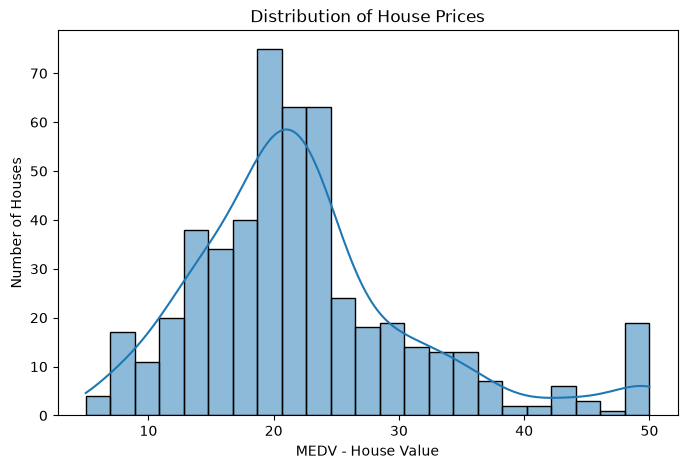

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MEDV"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("MEDV - House Value")
plt.ylabel("Number of Houses")

plt.show()

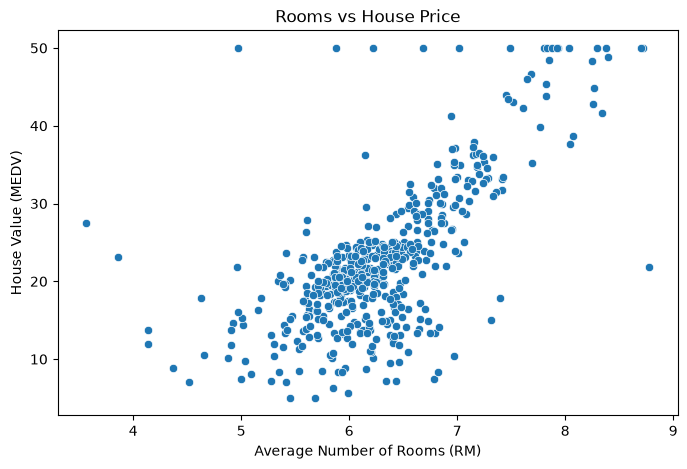

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["RM"], y=df["MEDV"])

plt.title("Rooms vs House Price")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Value (MEDV)")

plt.show()

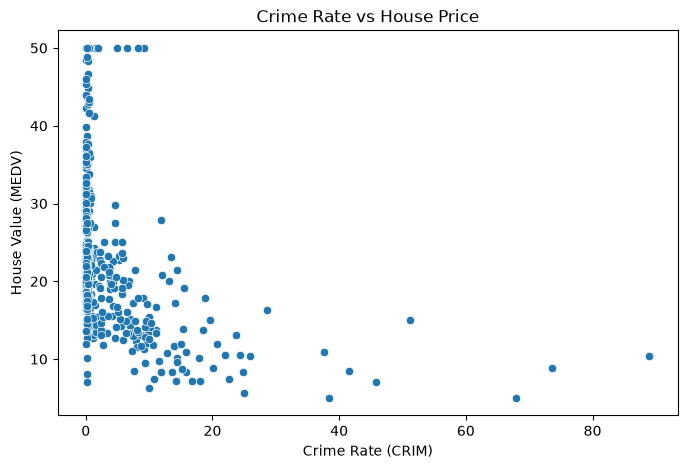

In [35]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["CRIM"], y=df["MEDV"])

plt.title("Crime Rate vs House Price")
plt.xlabel("Crime Rate (CRIM)")
plt.ylabel("House Value (MEDV)")

plt.show()

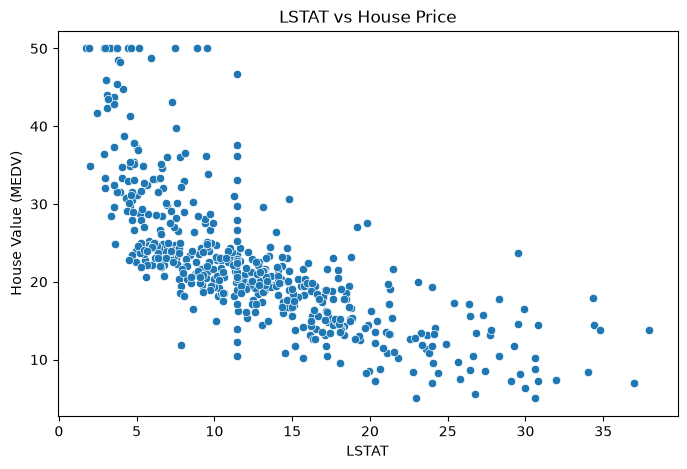

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["LSTAT"], y=df["MEDV"])

plt.title("LSTAT vs House Price")
plt.xlabel("LSTAT")
plt.ylabel("House Value (MEDV)")

plt.show()

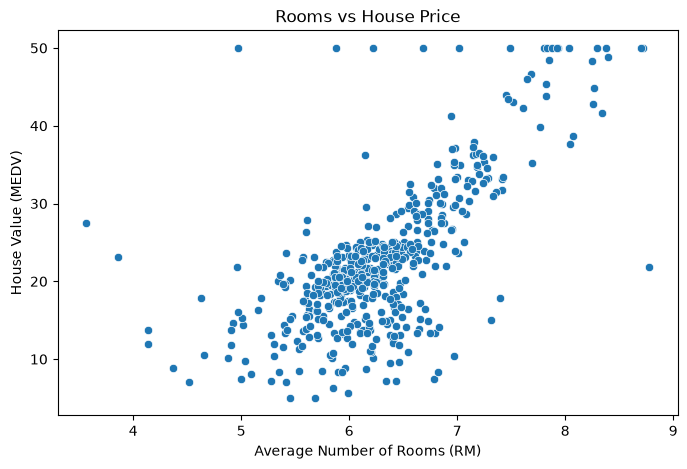

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["RM"], y=df["MEDV"])

plt.title("Rooms vs House Price")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Value (MEDV)")

plt.show()

In [39]:
correlation = df.corr()

print(correlation["MEDV"].sort_values(ascending=False))

MEDV       1.000000
RM         0.695360
ZN         0.362292
B          0.333461
DIS        0.249929
CHAS       0.183844
AGE       -0.377572
RAD       -0.381626
CRIM      -0.383895
NOX       -0.427321
TAX       -0.468536
INDUS     -0.476394
PTRATIO   -0.507787
LSTAT     -0.723093
Name: MEDV, dtype: float64


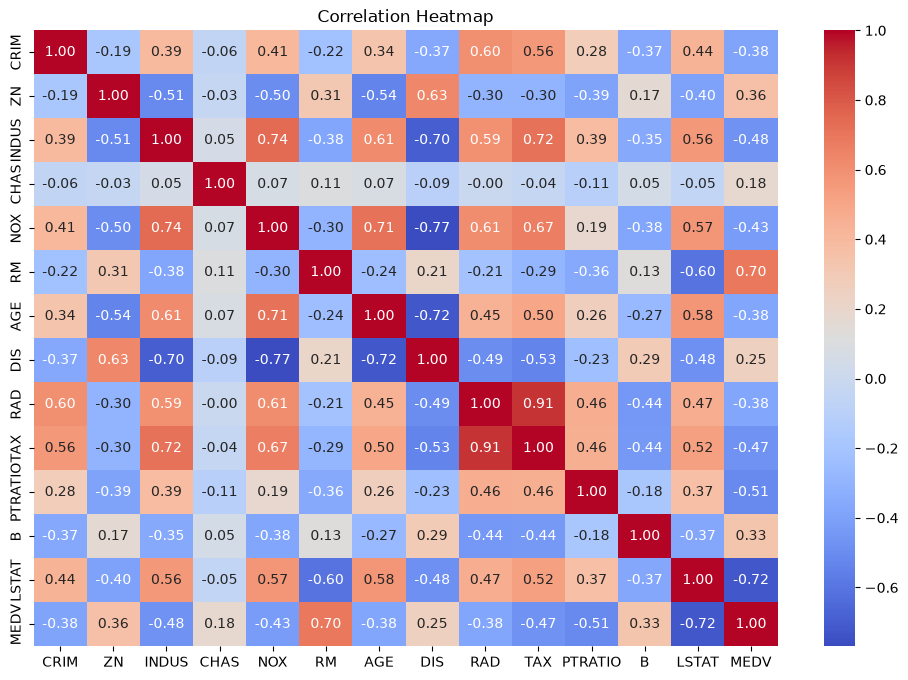

In [40]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

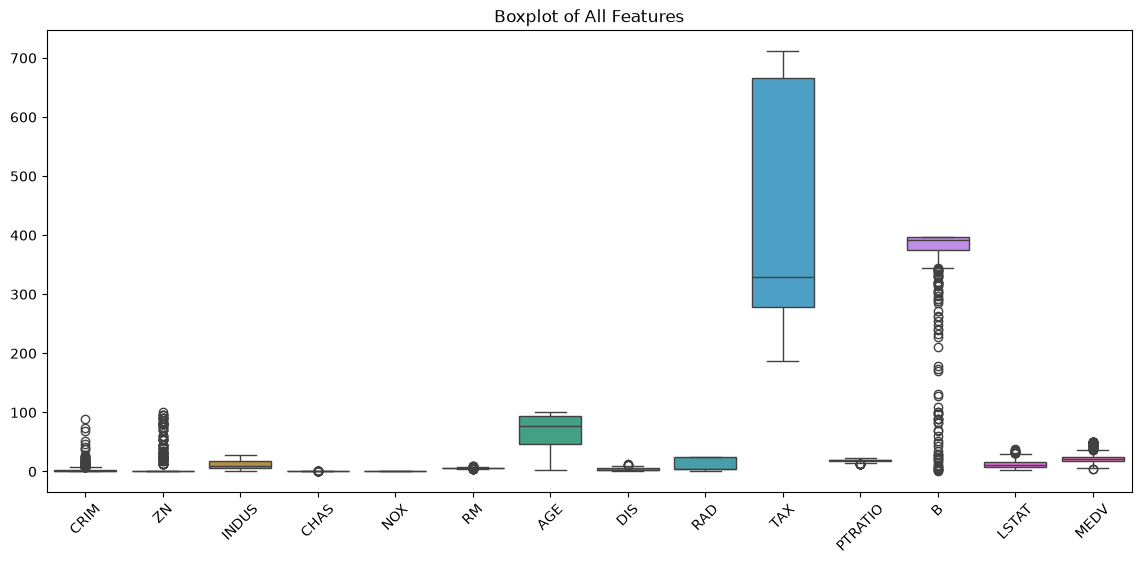

In [41]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df)

plt.title("Boxplot of All Features")
plt.xticks(rotation=45)
plt.show()

ML pipeline

In [42]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (404, 13)
X_test : (102, 13)
y_train: (404,)
y_test : (102,)


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [45]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [46]:
("imputer", SimpleImputer(strategy="median"))

('imputer', SimpleImputer(strategy='median'))

In [47]:
("scaler", StandardScaler())

('scaler', StandardScaler())

In [48]:
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)

X_test_scaled = preprocessing_pipeline.transform(X_test)

In [51]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

In [52]:
print("Actual:", y_test.values[:5])
print("Predicted:", y_pred_linear[:5])

Actual: [23.6 32.4 13.6 22.8 16.1]
Predicted: [29.02290756 36.51654453 14.53930169 25.0600581  18.39672661]


In [53]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Performance
-----------------------------
MAE : 3.1487373170237607
MSE : 24.999384790103356
RMSE: 4.999938478631848
R²  : 0.6591013893903512


In [54]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train_scaled, y_train)

y_pred_tree = decision_tree.predict(X_test_scaled)

print("First 5 Actual values:")
print(y_test.values[:5])

print("\nFirst 5 Predicted values:")
print(y_pred_tree[:5])

First 5 Actual values:
[23.6 32.4 13.6 22.8 16.1]

First 5 Predicted values:
[25.  32.  15.2 25.  15.2]


In [55]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("-------------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Performance
-------------------------
MAE : 2.947058823529412
MSE : 18.920196078431374
RMSE: 4.349735173367613
R²  : 0.7419989087830383


In [56]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train_scaled, y_train)

y_pred_rf = random_forest.predict(X_test_scaled)

print("First 5 Actual values:")
print(y_test.values[:5])

print("\nFirst 5 Predicted values:")
print(y_pred_rf[:5])

First 5 Actual values:
[23.6 32.4 13.6 22.8 16.1]

First 5 Predicted values:
[23.229 30.826 16.798 23.603 17.092]


In [57]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Performance
------------------------
MAE : 2.0740882352941177
MSE : 8.381215950980392
RMSE: 2.89503297925609
R²  : 0.885711392624361


In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(X_train_scaled, y_train)

y_pred_gb = gradient_boosting.predict(X_test_scaled)

print("First 5 Actual values:")
print(y_test.values[:5])

print("\nFirst 5 Predicted values:")
print(y_pred_gb[:5])

First 5 Actual values:
[23.6 32.4 13.6 22.8 16.1]

First 5 Predicted values:
[23.22824078 31.33239342 16.74906784 23.6723761  17.57191369]


In [59]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)


Gradient Boosting Performance
-----------------------------
MAE : 1.9450096921911626
MSE : 7.527202360170628
RMSE: 2.743574741130744
R²  : 0.8973569610650716


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

In [61]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

In [62]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5]
}

In [63]:
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.

In [64]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

Best CV Score:
-13.687087972568744


In [65]:
best_gb_model = grid_search.best_estimator_

print("\nBest Model:")
print(best_gb_model)


Best Model:
GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)


In [66]:
GradientBoostingRegressor(
    learning_rate=0.05,
    n_estimators=200,
    max_depth=3,
    min_samples_split=2,
    random_state=42
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [67]:
# Make predictions using the tuned model

y_pred_tuned = best_gb_model.predict(X_test_scaled)

print("First 5 Actual values:")
print(y_test.values[:5])

print("\nFirst 5 Tuned Predictions:")
print(y_pred_tuned[:5])

First 5 Actual values:
[23.6 32.4 13.6 22.8 16.1]

First 5 Tuned Predictions:
[23.66735217 30.65006014 16.29175099 23.97068013 17.54290464]


In [68]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\nTuned Gradient Boosting Performance")
print("-----------------------------------")
print("MAE :", mae_tuned)
print("MSE :", mse_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)


Tuned Gradient Boosting Performance
-----------------------------------
MAE : 1.9772182252097676
MSE : 7.728238278657133
RMSE: 2.7799709132753767
R²  : 0.894615578992269


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5]
}

final_grid = GridSearchCV(
    estimator=final_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

final_grid.fit(X_train, y_train)

print("Best Parameters:")
print(final_grid.best_params_)

print("\nBest CV Score:")
print(final_grid.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV Score:
-13.684629127019383


In [70]:
best_final_model = final_grid.best_estimator_

y_pred_final = best_final_model.predict(X_test)

print("First 5 Actual values:")
print(y_test.values[:5])

print("\nFirst 5 Final Predictions:")
print(y_pred_final[:5])

First 5 Actual values:
[23.6 32.4 13.6 22.8 16.1]

First 5 Final Predictions:
[23.66735217 30.65006014 16.29175099 23.97068013 17.54290464]


In [71]:
mae_final = mean_absolute_error(y_test, y_pred_final)
mse_final = mean_squared_error(y_test, y_pred_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test, y_pred_final)

print("\nFinal Gradient Boosting Performance")
print("-----------------------------------")
print("MAE :", mae_final)
print("MSE :", mse_final)
print("RMSE:", rmse_final)
print("R²  :", r2_final)


Final Gradient Boosting Performance
-----------------------------------
MAE : 1.9775232078497196
MSE : 7.729330433804857
RMSE: 2.780167339173104
R²  : 0.8946006860588805


In [73]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [75]:
import joblib

best_final_model = final_grid.best_estimator_

joblib.dump(
    best_final_model,
    "models/best_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [76]:
new_house = pd.DataFrame({
    "CRIM": [0.1],
    "ZN": [20],
    "INDUS": [5],
    "CHAS": [0],
    "NOX": [0.5],
    "RM": [6.5],
    "AGE": [50],
    "DIS": [5],
    "RAD": [5],
    "TAX": [300],
    "PTRATIO": [15],
    "B": [390],
    "LSTAT": [5]
})

print(new_house)

   CRIM  ZN  INDUS  CHAS  NOX   RM  AGE  DIS  RAD  TAX  PTRATIO    B  LSTAT
0   0.1  20      5     0  0.5  6.5   50    5    5  300       15  390      5


In [78]:
import joblib

model = joblib.load("models/best_model.pkl")

prediction = model.predict(new_house)

print("Predicted House Value:", prediction[0])

Predicted House Value: 26.53137928453263


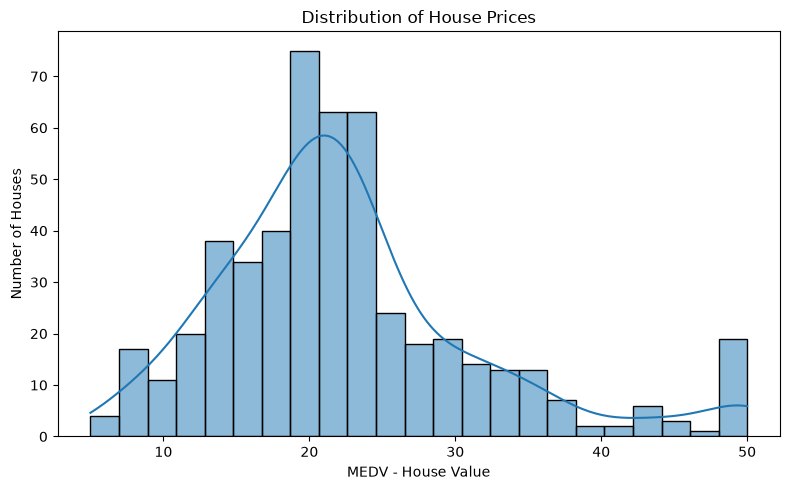

In [80]:
plt.figure(figsize=(8, 5))

sns.histplot(df["MEDV"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("MEDV - House Value")
plt.ylabel("Number of Houses")

plt.tight_layout()

plt.savefig(
    "reports/figures/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

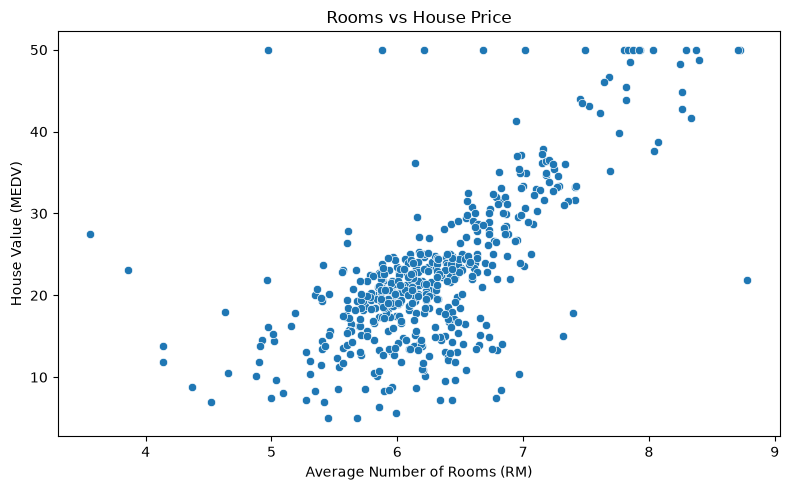

In [81]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df["RM"], y=df["MEDV"])

plt.title("Rooms vs House Price")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Value (MEDV)")

plt.tight_layout()

plt.savefig(
    "reports/figures/rooms_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

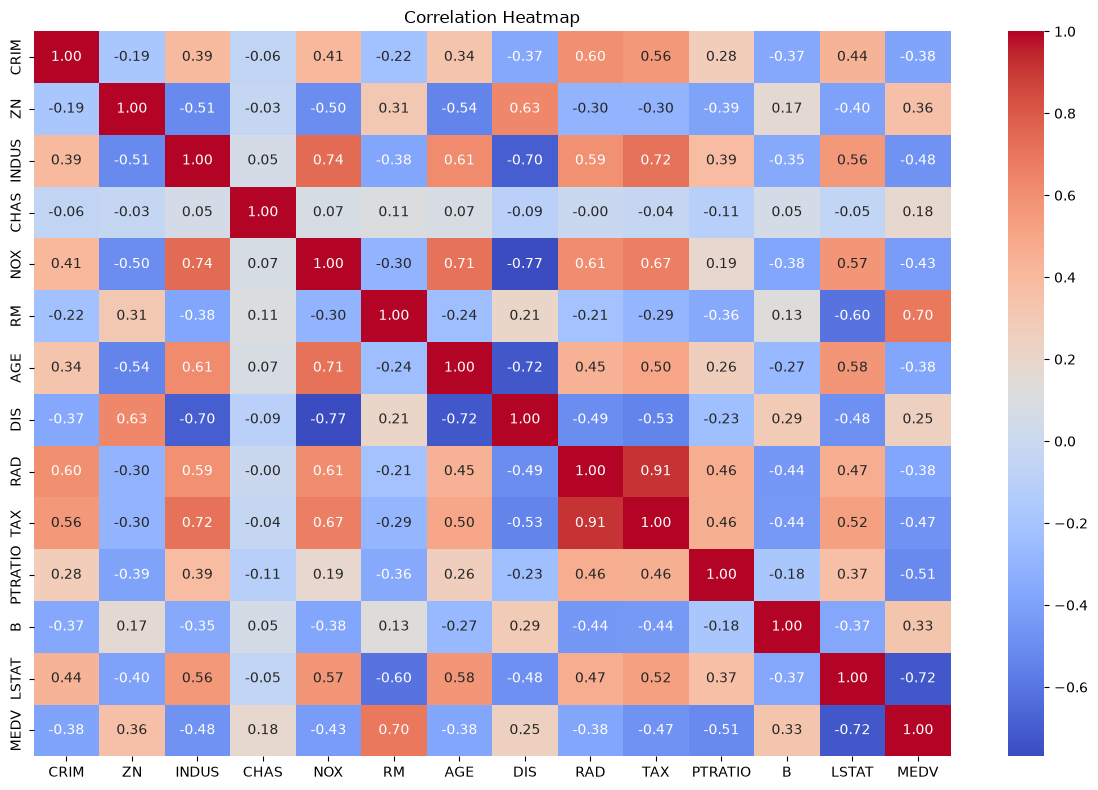

In [82]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

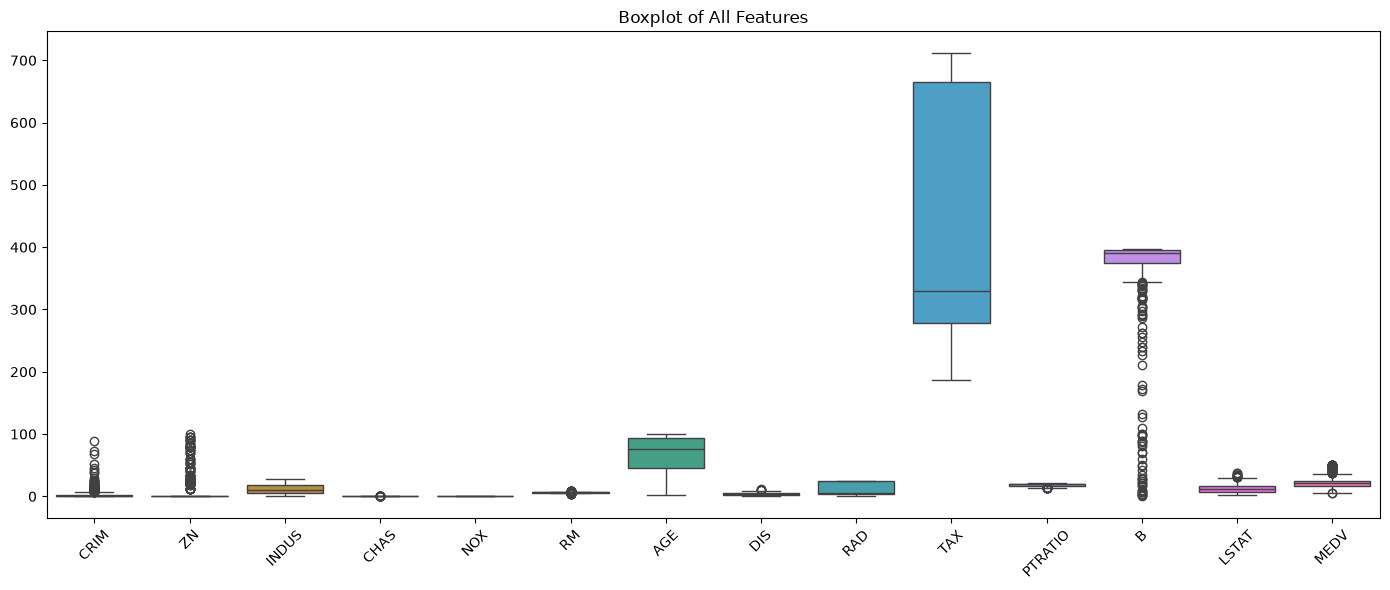

In [83]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df)

plt.title("Boxplot of All Features")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "reports/figures/feature_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()